# Notebook 2 - Preprocessing, Labeling, dan Pelatihan Model Sentimen

Notebook ini memproses raw review dari `raw_review_klikindomaret_playstore.csv`, melakukan preprocessing teks, labeling sentimen berbasis lexicon, menyimpan dataset final, lalu melatih model klasifikasi sentiment analysis.

In [1]:
%pip install -q pandas==2.2.2 numpy==1.26.4 matplotlib==3.8.4 scikit-learn==1.4.2 Sastrawi==1.0.1

Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [12 lines of output]
  + meson setup C:\Users\LENOVO\AppData\Local\Temp\pip-install-jbxify5i\pandas_ebd466f8b366430e9ce41e29c801c329 C:\Users\LENOVO\AppData\Local\Temp\pip-install-jbxify5i\pandas_ebd466f8b366430e9ce41e29c801c329\.mesonpy-wver01ej\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\LENOVO\AppData\Local\Temp\pip-install-jbxify5i\pandas_ebd466f8b366430e9ce41e29c801c329\.mesonpy-wver01ej\build\meson-python-native-file.ini
  The Meson build system
  Version: 1.2.1
  Source dir: C:\Users\LENOVO\AppData\Local\Temp\pip-install-jbxify5i\pandas_ebd466f8b366430e9ce41e29c801c329
  Build dir: C:\Users\LENOVO\AppData\Local\Temp\pip-install-jbxify5i\pandas_ebd466f8b366430e9ce41e29c801c329\.mesonpy-wver01ej\build
  Build type: native build
  Project name: pandas
  Project version: 2.2.2
  
  ..\..\meson.build:2:0: ERROR: C

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    stopwords_id = set(StopWordRemoverFactory().get_stop_words())
    stemmer = StemmerFactory().create_stemmer()
except Exception as exc:
    print("Sastrawi tidak tersedia, gunakan fallback preprocessing tanpa stemming:", exc)
    stopwords_id = set()
    stemmer = None

RANDOM_STATE = 42
RAW_PATH = "raw_review_klikindomaret_playstore.csv"
FINAL_OUTPUT = "dataset_review_klikindomaret_playstore.csv"
LEXICON_PATH = "sentiment_lexicon_indonesia.csv"

APP_ID = "com.indomaret.klikindomaret"
APP_NAME = "Klik Indomaret"

In [3]:
raw_df = pd.read_csv(RAW_PATH)
print("RAW_COUNT_SEBELUM_PREPROCESSING =", len(raw_df))
print("Bentuk raw_df =", raw_df.shape)
print("Distribusi rating raw:")
print(raw_df["score"].value_counts().sort_index())
raw_df.head()

RAW_COUNT_SEBELUM_PREPROCESSING = 5000
Bentuk raw_df = (5000, 11)
Distribusi rating raw:
score
1    1000
2    1000
3    1000
4    1000
5    1000
Name: count, dtype: int64


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,f10ee8dd-476f-4865-8ce1-6aa83b277e7b,Nurul Lantika,https://play-lh.googleusercontent.com/a-/ALV-U...,jngn di download nyesel,1,0,2401101,2026-05-13 18:16:06,NaN,NaN,2401101
1,0e9008f6-872b-4c64-b3dd-d4d2ab21a7ad,Andra Winata,https://play-lh.googleusercontent.com/a-/ALV-U...,kecewa order di Indomart skrg stok banyak koso...,1,0,2604200,2026-05-13 18:04:31,NaN,NaN,2604200
2,c139cef1-5566-4086-a072-51c2b8e3af61,Indri Aprilliani,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasinya -100/10 beda banget sama alfagift,1,0,NaN,2026-05-13 17:20:07,NaN,NaN,NaN
3,938c2a68-fb03-40a8-8e79-8bf236230203,Fina Zee,https://play-lh.googleusercontent.com/a-/ALV-U...,makan tuh sendiri.promo.gula.minyak.beras.majo...,1,0,2604200,2026-05-13 16:52:53,NaN,NaN,2604200
4,aae08446-1e26-4bbb-8f7e-2cc4a0b453d9,ismi rizqi kamila,https://play-lh.googleusercontent.com/a-/ALV-U...,tolong di respon dengan baik terkait proses pe...,1,0,2604200,2026-05-13 16:19:21,NaN,NaN,2604200


## Preprocessing teks

Tahapan preprocessing mencakup: lowercasing, penghapusan URL, mention, hashtag, angka, punctuation, karakter non-huruf, normalisasi spasi, stopword removal, dan stemming.

In [ ]:
normalization_map = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "nggak": "tidak", "ngga": "tidak", "tdk": "tidak",
    "bgt": "banget", "bangettt": "banget", "apk": "aplikasi", "app": "aplikasi",
    "lemottt": "lemot", "eror": "error", "err": "error", "cs": "customer service",
    "mantab": "mantap", "mantul": "mantap", "recommended": "rekomendasi", "recomended": "rekomendasi"
}

def normalize_slang(text):
    tokens = text.split()
    return " ".join(normalization_map.get(token, token) for token in tokens)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = normalize_slang(text)
    tokens = [word for word in text.split() if word not in stopwords_id and len(word) > 1]
    text = " ".join(tokens)
    if stemmer is not None:
        text = stemmer.stem(text)
    return text

df = raw_df[["reviewId", "userName", "content", "score", "thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt", "appVersion"]].copy()
df = df.rename(columns={
    "reviewId": "review_id",
    "userName": "user_name",
    "content": "text",
    "score": "rating",
    "thumbsUpCount": "thumbs_up_count",
    "reviewCreatedVersion": "review_created_version",
    "at": "review_date",
    "replyContent": "developer_reply",
    "repliedAt": "developer_reply_date",
    "appVersion": "app_version"
})

df = df.dropna(subset=["text", "rating"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() >= 5].copy()
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

df[["text", "clean_text", "rating"]].head(10)

## Labeling sentiment berbasis lexicon

Label sentiment dibuat dari isi teks hasil preprocessing menggunakan file `sentiment_lexicon_indonesia.csv`. Kolom `rating` tidak digunakan untuk membuat label, hanya disimpan sebagai metadata.

In [ ]:
lexicon_df = pd.read_csv(LEXICON_PATH)
lexicon = dict(zip(lexicon_df["term"].astype(str), lexicon_df["score"].astype(int)))

def label_sentiment_from_lexicon(text):
    tokens = str(text).split()
    score = sum(lexicon.get(token, 0) for token in tokens)
    if score > 0:
        return "positif"
    if score < 0:
        return "negatif"
    return "netral"

df["sentiment"] = df["clean_text"].apply(label_sentiment_from_lexicon)

df["source_app"] = APP_NAME
df["source_package"] = APP_ID
df["source_url"] = f"https://play.google.com/store/apps/details?id={APP_ID}"
df["sumber_data"] = "Google Play Store scraping menggunakan google-play-scraper"

final_cols = [
    "review_id", "user_name", "review_date", "rating", "sentiment", "text", "clean_text",
    "thumbs_up_count", "review_created_version", "app_version", "developer_reply",
    "developer_reply_date", "source_app", "source_package", "source_url", "sumber_data"
]

df_final = df[[c for c in final_cols if c in df.columns]].reset_index(drop=True)
df_final.to_csv(FINAL_OUTPUT, index=False)

print("Dataset final disimpan ke:", FINAL_OUTPUT)
print("Jumlah dataset final:", len(df_final))
print("Distribusi label sentiment:")
print(df_final["sentiment"].value_counts())
df_final.head()

Dataset final disimpan ke: dataset_review_klikindomaret_playstore.csv
Jumlah dataset final: 4690
Distribusi label sentiment:
sentiment
negatif    2432
positif    1335
netral      923
Name: count, dtype: int64


,review_id,user_name,review_date,rating,sentiment,text,clean_text,thumbs_up_count,review_created_version,app_version,developer_reply,developer_reply_date,source_app,source_package,source_url,sumber_data
0,c139cef1-5566-4086-a072-51c2b8e3af61,Indri Aprilliani,2026-05-13 17:20:07,1,netral,aplikasinya -100/10 beda banget sama alfagift,aplikasinya beda banget sama alfagift,0,NaN,NaN,NaN,NaN,Klik Indomaret,com.indomaret.klikindomaret,https://play.google.com/store/apps/details?id=...,Google Play Store scraping menggunakan google-...
1,938c2a68-fb03-40a8-8e79-8bf236230203,Fina Zee,2026-05-13 16:52:53,1,negatif,makan tuh sendiri.promo.gula.minyak.beras.majo...,makan tuh sendiripromogulaminyakberasmajo seor...,0,2604200,2604200,NaN,NaN,Klik Indomaret,com.indomaret.klikindomaret,https://play.google.com/store/apps/details?id=...,Google Play Store scraping menggunakan google-...
2,aae08446-1e26-4bbb-8f7e-2cc4a0b453d9,ismi rizqi kamila,2026-05-13 16:19:21,1,negatif,tolong di respon dengan baik terkait proses pe...,tolong di respon dengan baik terkait proses pe...,0,2604200,2604200,NaN,NaN,Klik Indomaret,com.indomaret.klikindomaret,https://play.google.com/store/apps/details?id=...,Google Play Store scraping menggunakan google-...
3,d3087484-d2c9-49c3-8c4a-19dde619bd85,Siti Muthohiroh,2026-05-13 15:59:46,1,netral,pesan beras dr tgl 12 sekitar jam 14 sampe sek...,pesan beras dr tgl sekitar jam sampe sekarang ...,0,2604200,2604200,NaN,NaN,Klik Indomaret,com.indomaret.klikindomaret,https://play.google.com/store/apps/details?id=...,Google Play Store scraping menggunakan google-...
4,a2c9ef5b-538c-49af-9537-8cf6bf18744b,Dian Oskawati,2026-05-13 15:41:45,1,negatif,"tiap bulan minta update,kalau gak update gakbi...",tiap bulan minta updatekalau tidak update gakb...,1,2604100,2604100,NaN,NaN,Klik Indomaret,com.indomaret.klikindomaret,https://play.google.com/store/apps/details?id=...,Google Play Store scraping menggunakan google-...


## Pelatihan model machine learning

Model dilatih menggunakan `clean_text` sebagai fitur dan `sentiment` sebagai target. Data netral tetap tersimpan di dataset final, tetapi untuk pelatihan akhir fokus pada kelas positif dan negatif agar target klasifikasi lebih tegas.

In [ ]:
df_model = df_final[df_final["sentiment"].isin(["negatif", "positif"])].copy()

X = df_model["clean_text"]
y = df_model["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))
print("Distribusi train:")
print(y_train.value_counts())
print("Distribusi test:")
print(y_test.value_counts())

Jumlah data training: 3013
Jumlah data testing: 754
Distribusi train:
sentiment
negatif    1945
positif    1068
Name: count, dtype: int64
Distribusi test:
sentiment
negatif    487
positif    267
Name: count, dtype: int64


In [ ]:
models = {
    "TF-IDF + Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)),
        ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "TF-IDF + Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "TF-IDF + Multinomial NB": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ("clf", MultinomialNB())
    ])
}

results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    trained_models[model_name] = model
    results.append({"model": model_name, "accuracy": acc})
    print("\n===", model_name, "===")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

result_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
result_df


=== TF-IDF + Linear SVM ===
Accuracy: 0.9442970822281167
              precision    recall  f1-score   support

     negatif       0.95      0.97      0.96       487
     positif       0.93      0.91      0.92       267

    accuracy                           0.94       754
   macro avg       0.94      0.94      0.94       754
weighted avg       0.94      0.94      0.94       754




=== TF-IDF + Logistic Regression ===
Accuracy: 0.9204244031830239
              precision    recall  f1-score   support

     negatif       0.93      0.95      0.94       487
     positif       0.91      0.86      0.88       267

    accuracy                           0.92       754
   macro avg       0.92      0.91      0.91       754
weighted avg       0.92      0.92      0.92       754




=== TF-IDF + Multinomial NB ===
Accuracy: 0.8620689655172413
              precision    recall  f1-score   support

     negatif       0.83      0.99      0.90       487
     positif       0.98      0.63      0.76       267

    accuracy                           0.86       754
   macro avg       0.90      0.81      0.83       754
weighted avg       0.88      0.86      0.85       754



,model,accuracy
0,TF-IDF + Linear SVM,0.944297
1,TF-IDF + Logistic Regression,0.920424
2,TF-IDF + Multinomial NB,0.862069


Model terbaik: TF-IDF + Linear SVM
Accuracy testing: 0.9442970822281167


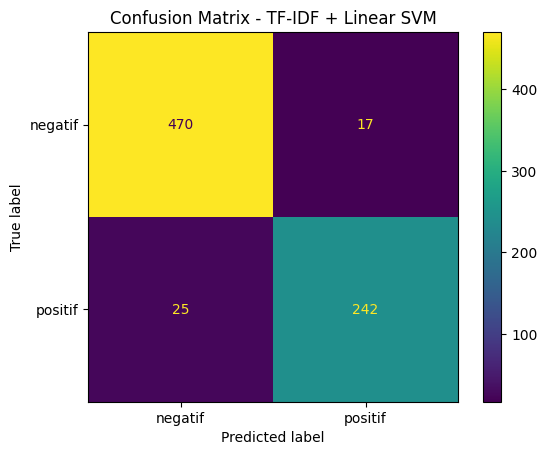

In [ ]:
best_name = result_df.iloc[0]["model"]
best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)

print("Model terbaik:", best_name)
print("Accuracy testing:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

In [ ]:
contoh_review = [
    "Aplikasinya sangat membantu dan mudah digunakan",
    "Sering error dan tidak bisa login",
    "Lumayan, tapi masih perlu banyak perbaikan"
]

contoh_clean = [clean_text(teks) for teks in contoh_review]
for teks, label in zip(contoh_review, best_model.predict(contoh_clean)):
    print(f"{teks} -> {label}")

Aplikasinya sangat membantu dan mudah digunakan -> positif
Sering error dan tidak bisa login -> negatif
Lumayan, tapi masih perlu banyak perbaikan -> positif


## Catatan untuk reviewer

- Notebook 1 hanya berisi scraping dan penyimpanan raw CSV.
- Notebook 2 berisi preprocessing, labeling, penyimpanan dataset final, dan pelatihan model.
- Label sentiment dibuat dari teks review menggunakan lexicon, bukan dari rating.
- Preprocessing mencakup lowercasing, penghapusan angka, mention, hashtag, punctuation, stopword removal, dan stemming.